# Prediksi Curah Hujan di Kota Bandung Menggunakan Random Forest Regressor

**Identitas Mahasiswa:**
- **Nama:** Adnan Fariz Irawan
- **NIM:** 20124006
- **Kelas:** C1'24 informatika
- **Kelompok:** 3

**Deskripsi Proyek:**
Notebook ini bertujuan untuk menganalisis dan memprediksi jumlah curah hujan bulanan di Kota Bandung menggunakan algoritma *Machine Learning* Random Forest Regressor. Dataset yang digunakan berasal dari Open Data Jawa Barat.

Proyek ini menggunakan pendekatan Supervised Learning Regresi untuk memecahkan masalah Time Series Forecasting. Data deret waktu diubah menjadi format tabular dengan mengekstrak komponen waktu (Tahun dan Bulan) sebagai fitur independen (X) untuk memprediksi target kontinu berupa jumlah curah hujan (y) menggunakan algoritma Random Forest Regressor."

Import Kernel dari file venv di folder PML-KELOMPOK3 ini

In [89]:
import sys
import subprocess

packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn']
subprocess.check_call(['uv', 'pip', 'install', '--python', sys.executable, *packages])
print('Package sudah terpasang di kernel:', sys.executable)

Package sudah terpasang di kernel: d:\KULIAH ADNAN\SEMESTER 4\Pemrograman Python (Maching Learning) - Pak Adhi Rahadian\pml-kelompok3\.venv\Scripts\python.exe


In [90]:
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns

try:
    import notebook
    jupyter_ver = notebook.__version__
except ImportError:
    try:
        import jupyterlab
        jupyter_ver = jupyterlab.__version__
    except ImportError:
        jupyter_ver = 'Cek manual di Extension VS Code'

print('=' * 40)
print('CEK VERSI LIBRARY DATA SCIENCE')
print('=' * 40)
print(f'Python           : {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}')
print(f'NumPy            : {np.__version__}')
print(f'Pandas           : {pd.__version__}')
print(f'Scikit-Learn     : {sklearn.__version__}')
print(f'Matplotlib       : {matplotlib.__version__}')
print(f'Seaborn          : {sns.__version__}')
print(f'Jupyter/Notebook : {jupyter_ver}')
print('=' * 40)

CEK VERSI LIBRARY DATA SCIENCE
Python           : 3.14.5
NumPy            : 2.5.0
Pandas           : 3.0.3
Scikit-Learn     : 1.9.0
Matplotlib       : 3.11.0
Seaborn          : 0.13.2
Jupyter/Notebook : Cek manual di Extension VS Code


## 1. Import Library
Pada tahap ini, kita mengimpor semua library yang diperlukan untuk pengolahan data, 
visualisasi, dan pembuatan model machine learning.

In [91]:
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns

try:
    import notebook
    jupyter_ver = notebook.__version__
except ImportError:
    try:
        import jupyterlab
        jupyter_ver = jupyterlab.__version__
    except ImportError:
        jupyter_ver = 'Cek manual di Extension VS Code'

print('=' * 40)
print('CEK VERSI LIBRARY DATA SCIENCE')
print('=' * 40)
print(f'Python           : {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}')
print(f'NumPy            : {np.__version__}')
print(f'Pandas           : {pd.__version__}')
print(f'Scikit-Learn     : {sklearn.__version__}')
print(f'Matplotlib       : {matplotlib.__version__}')
print(f'Seaborn          : {sns.__version__}')
print(f'Jupyter/Notebook : {jupyter_ver}')
print('=' * 40)

CEK VERSI LIBRARY DATA SCIENCE
Python           : 3.14.5
NumPy            : 2.5.0
Pandas           : 3.0.3
Scikit-Learn     : 1.9.0
Matplotlib       : 3.11.0
Seaborn          : 0.13.2
Jupyter/Notebook : Cek manual di Extension VS Code


In [92]:
# Import library untuk pengolahan data
import pandas as pd
import numpy as np

# Import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk machine learning
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Mengatur style visualisasi
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("✅ Semua library berhasil diimpor!")

✅ Semua library berhasil diimpor!


## 2. Load Dataset
Memuat dataset curah hujan Kota Bandung dari file CSV dan menampilkan beberapa baris pertama untuk melihat struktur data.

In [93]:
# Membaca dataset
# Path absolut supaya pasti ketemu walaupun notebook dijalankan dari folder mana pun
csv_path = r'D:\KULIAH ADNAN\SEMESTER 4\Pemrograman Python (Maching Learning) - Pak Adhi Rahadian\pml-kelompok3\src\data\curah_hujan_di_kota_bandung_2.csv'

# Membaca CSV
df = pd.read_csv(csv_path)

# Menampilkan 5 baris pertama data
df.head()


,id,kode_provinsi,nama_provinsi,bps_kode_kabupaten_kota,bps_nama_kabupaten_kota,bulan,jumlah_curah_hujan,satuan,tahun
0,1,32,JAWA BARAT,3273,KOTA BANDUNG,JANUARI,65.3,MM,2017
1,2,32,JAWA BARAT,3273,KOTA BANDUNG,FEBRUARI,199.3,MM,2017
2,3,32,JAWA BARAT,3273,KOTA BANDUNG,MARET,389.3,MM,2017
3,4,32,JAWA BARAT,3273,KOTA BANDUNG,APRIL,220.2,MM,2017
4,5,32,JAWA BARAT,3273,KOTA BANDUNG,MEI,222.3,MM,2017


## 3. Persiapan Data & Deteksi Outlier
Pada tahap ini, kita akan membuat kolom tanggal untuk memudahkan analisis time series dan mendeteksi outlier menggunakan metode IQR (Interquartile Range).

📊 Batas atas normal: 602.58 MM
️  Jumlah outlier terdeteksi: 2

Data outlier:


,tanggal,bulan,tahun,jumlah_curah_hujan
56,2021-09-01,SEPTEMBER,2021,773.0
59,2021-12-01,DESEMBER,2021,1985.0


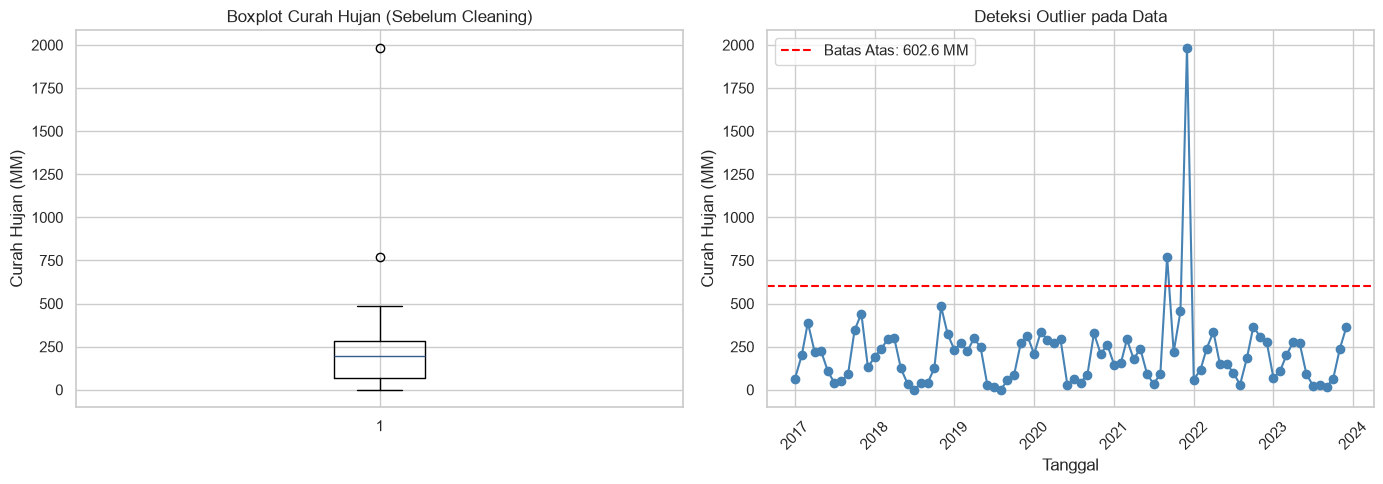

In [94]:
# ========================================
# PERSIAPAN DATA & DETEKSI OUTLIER
# ========================================

# Buat kolom tanggal & bulan_angka untuk plotting
bulan_map = {
    'JANUARI': 1, 'FEBRUARI': 2, 'MARET': 3, 'APRIL': 4,
    'MEI': 5, 'JUNI': 6, 'JULI': 7, 'AGUSTUS': 8,
    'SEPTEMBER': 9, 'OKTOBER': 10, 'NOVEMBER': 11, 'DESEMBER': 12
}

df['bulan_angka'] = df['bulan'].str.upper().map(bulan_map)
df['tanggal'] = pd.to_datetime(df['tahun'].astype(str) + '-' + df['bulan_angka'].astype(str) + '-01')
df = df.sort_values('tanggal').reset_index(drop=True)

# ========================================
# DETEKSI OUTLIER dengan IQR Method
# ========================================
Q1 = df['jumlah_curah_hujan'].quantile(0.25)
Q3 = df['jumlah_curah_hujan'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[df['jumlah_curah_hujan'] > upper_bound]
print(f"📊 Batas atas normal: {upper_bound:.2f} MM")
print(f"️  Jumlah outlier terdeteksi: {len(outliers)}")
print("\nData outlier:")
display(outliers[['tanggal', 'bulan', 'tahun', 'jumlah_curah_hujan']])

# Visualisasi outlier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['jumlah_curah_hujan'], orientation='vertical')
axes[0].set_title('Boxplot Curah Hujan (Sebelum Cleaning)', fontsize=12)
axes[0].set_ylabel('Curah Hujan (MM)')

axes[1].plot(df['tanggal'], df['jumlah_curah_hujan'], marker='o', linestyle='-', color='steelblue')
axes[1].axhline(y=upper_bound, color='red', linestyle='--', label=f'Batas Atas: {upper_bound:.1f} MM')
axes[1].set_title('Deteksi Outlier pada Data', fontsize=12)
axes[1].set_xlabel('Tanggal')
axes[1].set_ylabel('Curah Hujan (MM)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis (EDA)
Melakukan analisis eksplorasi untuk memahami karakteristik data, seperti informasi umum, statistik deskriptif, dan mengecek apakah ada data yang hilang (missing values).

In [95]:
# Melihat informasi umum dataset (tipe data, jumlah baris)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       84 non-null     int64         
 1   kode_provinsi            84 non-null     int64         
 2   nama_provinsi            84 non-null     str           
 3   bps_kode_kabupaten_kota  84 non-null     int64         
 4   bps_nama_kabupaten_kota  84 non-null     str           
 5   bulan                    84 non-null     str           
 6   jumlah_curah_hujan       84 non-null     float64       
 7   satuan                   84 non-null     str           
 8   tahun                    84 non-null     int64         
 9   bulan_angka              84 non-null     int64         
 10  tanggal                  84 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(5), str(4)
memory usage: 7.3 KB


In [96]:
# Statistik deskriptif untuk kolom numerik
df.describe()

,id,kode_provinsi,bps_kode_kabupaten_kota,jumlah_curah_hujan,tahun,bulan_angka,tanggal
count,84.000000,84.0,84.0,84.000000,84.000000,84.000000,84
mean,42.500000,32.0,3273.0,210.198810,2020.000000,6.500000,2020-06-16 01:08:34.285714
min,1.000000,32.0,3273.0,0.200000,2017.000000,1.000000,2017-01-01 00:00:00
25%,21.750000,32.0,3273.0,66.575000,2018.000000,3.750000,2018-09-23 12:00:00
50%,42.500000,32.0,3273.0,195.150000,2020.000000,6.500000,2020-06-16 00:00:00
75%,63.250000,32.0,3273.0,280.975000,2022.000000,9.250000,2022-03-08 18:00:00
max,84.000000,32.0,3273.0,1985.000000,2023.000000,12.000000,2023-12-01 00:00:00
std,24.392622,0.0,0.0,238.948352,2.012012,3.472786,NaN


In [97]:
# Mengecek apakah ada data yang hilang (missing values)
print("Jumlah missing values per kolom:")
print(df.isnull().sum())

Jumlah missing values per kolom:
id                         0
kode_provinsi              0
nama_provinsi              0
bps_kode_kabupaten_kota    0
bps_nama_kabupaten_kota    0
bulan                      0
jumlah_curah_hujan         0
satuan                     0
tahun                      0
bulan_angka                0
tanggal                    0
dtype: int64


### 4.1 Visualisasi Data
Melihat tren curah hujan dari waktu ke waktu dan pola musiman rata-rata per bulan.

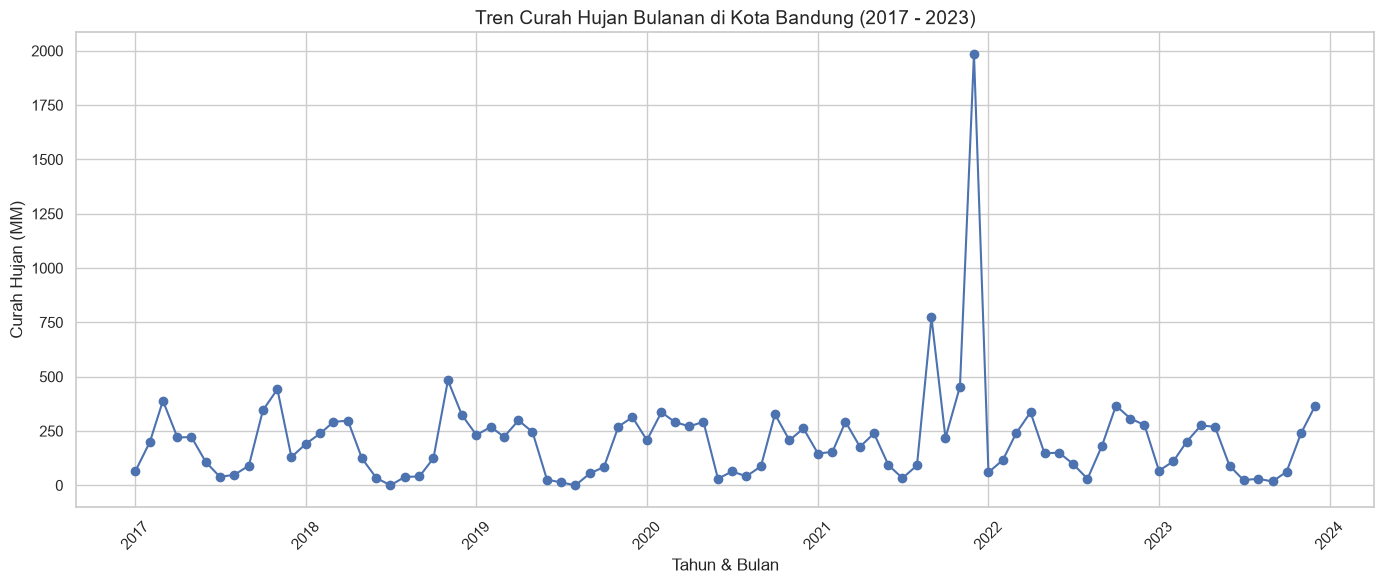

In [98]:
# Plot tren curah hujan dari tahun ke tahun
plt.figure(figsize=(14, 6))
plt.plot(df['tanggal'], df['jumlah_curah_hujan'], marker='o', linestyle='-', color='b')
plt.title('Tren Curah Hujan Bulanan di Kota Bandung (2017 - 2023)', fontsize=14)
plt.xlabel('Tahun & Bulan', fontsize=12)
plt.ylabel('Curah Hujan (MM)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

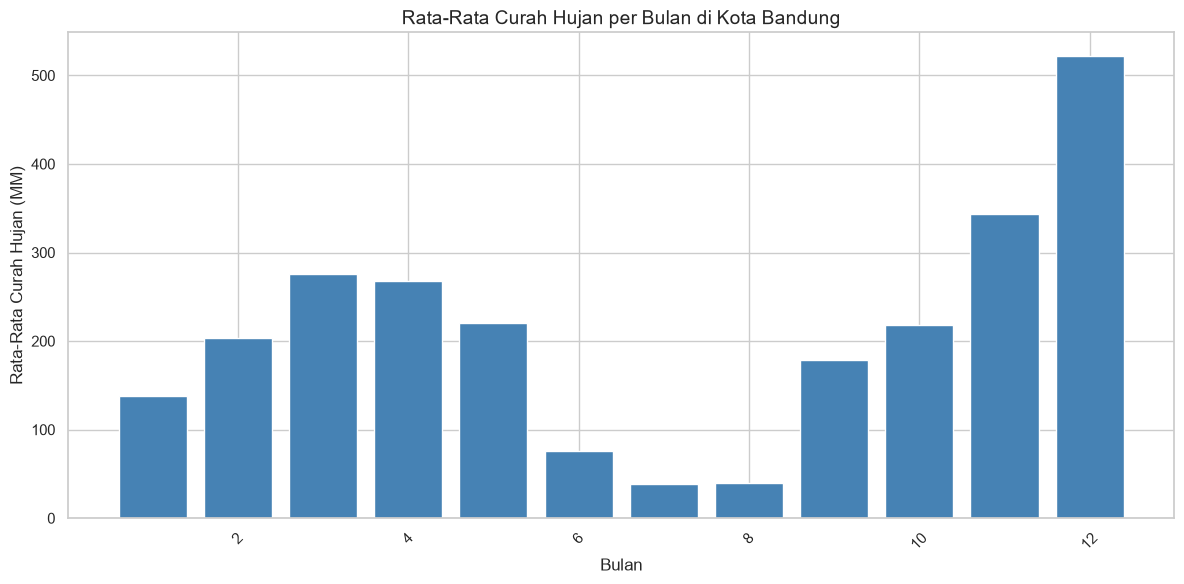

In [99]:
# Rata-rata curah hujan per bulan
rata_rata_bulanan = df.groupby('bulan_angka')['jumlah_curah_hujan'].mean()

plt.figure(figsize=(12, 6))
plt.bar(rata_rata_bulanan.index, rata_rata_bulanan.values, color='steelblue')
plt.title('Rata-Rata Curah Hujan per Bulan di Kota Bandung', fontsize=14)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Rata-Rata Curah Hujan (MM)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.2 Handling Outlier
Membersihkan data outlier menggunakan metode capping.

✅ Outlier berhasil di-cap ke 602.58 MM
📉 Nilai max sebelum cleaning: 1985.00 MM
 Nilai max setelah cleaning : 602.58 MM


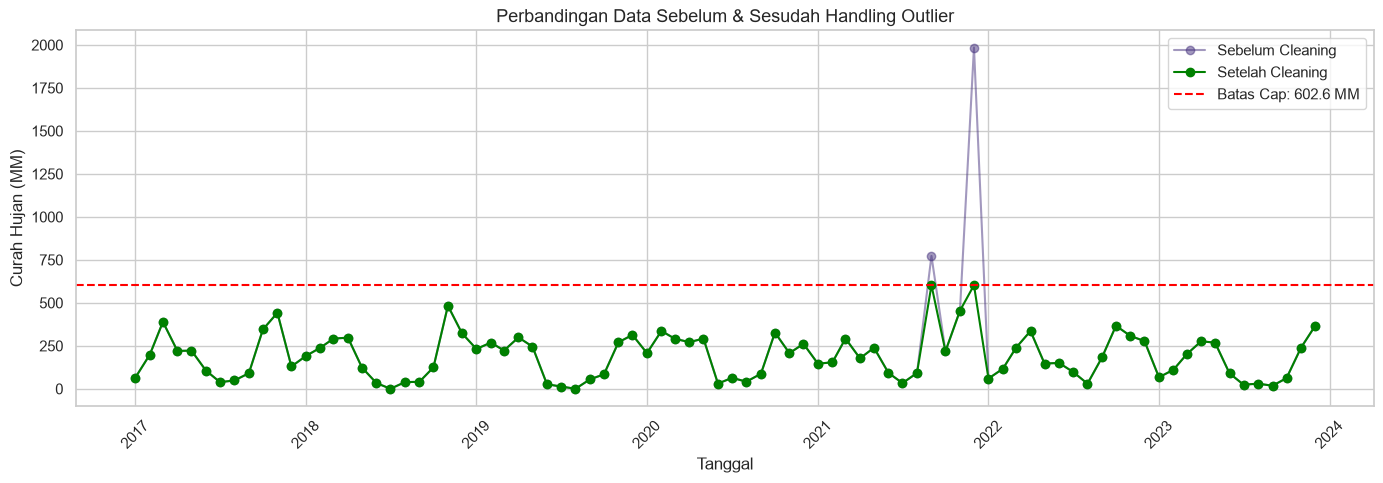

In [100]:
# ========================================
# HANDLING OUTLIER - Capping Method
# ========================================
# Kita cap outlier ke batas atas (upper_bound), bukan menghapusnya
# Agar urutan waktu tetap utuh untuk time series

df_clean = df.copy()
df_clean['jumlah_curah_hujan_original'] = df_clean['jumlah_curah_hujan']
df_clean['jumlah_curah_hujan'] = df_clean['jumlah_curah_hujan'].clip(upper=upper_bound)

print(f"✅ Outlier berhasil di-cap ke {upper_bound:.2f} MM")
print(f"📉 Nilai max sebelum cleaning: {df['jumlah_curah_hujan'].max():.2f} MM")
print(f" Nilai max setelah cleaning : {df_clean['jumlah_curah_hujan'].max():.2f} MM")

# Visualisasi sebelum vs sesudah
plt.figure(figsize=(14, 5))
plt.plot(df['tanggal'], df['jumlah_curah_hujan'], marker='o', label='Sebelum Cleaning', alpha=0.5)
plt.plot(df_clean['tanggal'], df_clean['jumlah_curah_hujan'], marker='o', color='green', label='Setelah Cleaning')
plt.axhline(y=upper_bound, color='red', linestyle='--', label=f'Batas Cap: {upper_bound:.1f} MM')
plt.title('Perbandingan Data Sebelum & Sesudah Handling Outlier', fontsize=13)
plt.xlabel('Tanggal')
plt.ylabel('Curah Hujan (MM)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Feature Engineering & Data Preprocessing
Membuat fitur tambahan agar Random Forest bisa melakukan forecasting dengan baik. Fitur yang ditambahkan:
- **Lag Features**: Curah hujan bulan-bulan sebelumnya (lag_1, lag_2, lag_3)
- **Rolling Statistics**: Rata-rata dan standar deviasi 3 bulan terakhir
- **Seasonal Encoding**: Sinus dan cosinus bulan untuk menangkap pola musiman

In [101]:
# ========================================
# FEATURE ENGINEERING - TIME SERIES
# ========================================
# Ini agar Random Forest bisa melakukan forecasting!

df_model = df_clean.copy()

# 1. LAG FEATURES (curah hujan bulan-bulan sebelumnya)
for i in range(1, 4):
    df_model[f'lag_{i}'] = df_model['jumlah_curah_hujan'].shift(i)

# 2. ROLLING STATISTICS (rata-rata & std dev window 3 bulan)
df_model['rolling_mean_3'] = df_model['jumlah_curah_hujan'].rolling(window=3).mean()
df_model['rolling_std_3'] = df_model['jumlah_curah_hujan'].rolling(window=3).std()

# 3. SEASONAL ENCODING (sin/cos agar model tahu Desember dekat dengan Januari)
df_model['bulan_sin'] = np.sin(2 * np.pi * df_model['bulan_angka'] / 12)
df_model['bulan_cos'] = np.cos(2 * np.pi * df_model['bulan_angka'] / 12)

# 4. Hapus baris yang mengandung NaN (karena lag & rolling)
df_model = df_model.dropna().reset_index(drop=True)

print(f"✅ Feature engineering selesai!")
print(f"📊 Jumlah fitur baru: 7 (lag_1, lag_2, lag_3, rolling_mean_3, rolling_std_3, bulan_sin, bulan_cos)")
print(f"📉 Jumlah data setelah drop NaN: {len(df_model)} baris")
print(f"\nFitur yang akan digunakan:")
display(df_model[['tanggal', 'tahun', 'bulan_angka', 'lag_1', 'lag_2', 'lag_3', 
                   'rolling_mean_3', 'bulan_sin', 'bulan_cos', 'jumlah_curah_hujan']].head())

✅ Feature engineering selesai!
📊 Jumlah fitur baru: 7 (lag_1, lag_2, lag_3, rolling_mean_3, rolling_std_3, bulan_sin, bulan_cos)
📉 Jumlah data setelah drop NaN: 81 baris

Fitur yang akan digunakan:


,tanggal,tahun,bulan_angka,lag_1,lag_2,lag_3,rolling_mean_3,bulan_sin,bulan_cos,jumlah_curah_hujan
0,2017-04-01,2017,4,389.3,199.3,65.3,269.600000,8.660254e-01,-0.500000,220.2
1,2017-05-01,2017,5,220.2,389.3,199.3,277.266667,5.000000e-01,-0.866025,222.3
2,2017-06-01,2017,6,222.3,220.2,389.3,182.966667,1.224647e-16,-1.000000,106.4
3,2017-07-01,2017,7,106.4,222.3,220.2,122.600000,-5.000000e-01,-0.866025,39.1
4,2017-08-01,2017,8,39.1,106.4,222.3,64.633333,-8.660254e-01,-0.500000,48.4


## 6. Data Preprocessing
Memisahkan fitur (X) dan target (y) untuk pelatihan model.

In [102]:
# ========================================
# DATA PREPROCESSING - PERSIAPAN X DAN y
# ========================================

# Daftar fitur yang akan digunakan
fitur_list = ['tahun', 'bulan_angka', 'lag_1', 'lag_2', 'lag_3', 
              'rolling_mean_3', 'rolling_std_3', 'bulan_sin', 'bulan_cos']

# Pisahkan fitur (X) dan target (y)
X = df_model[fitur_list]
y = df_model['jumlah_curah_hujan']

print(f"📊 Shape X: {X.shape}")
print(f" Shape y: {y.shape}")
print(f"\nFitur yang digunakan:")
for i, f in enumerate(fitur_list, 1):
    print(f"  {i}. {f}")

📊 Shape X: (81, 9)
 Shape y: (81,)

Fitur yang digunakan:
  1. tahun
  2. bulan_angka
  3. lag_1
  4. lag_2
  5. lag_3
  6. rolling_mean_3
  7. rolling_std_3
  8. bulan_sin
  9. bulan_cos


## 7. Split Data
Membagi dataset menjadi data latih (training set) dan data uji (testing set). Kita menggunakan `shuffle=False` karena ini adalah data time series (berurutan waktu), agar model tidak belajar dari data masa depan.

In [103]:
# ========================================
# SPLIT DATA - TIME SERIES (TANPA SHUFFLE!)
# ========================================
# Kita split berdasarkan waktu: 80% awal untuk training, 20% akhir untuk testing

split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Tanggal untuk visualisasi
tanggal_test = df_model['tanggal'].iloc[split_idx:].values

print(f"✅ Split data selesai (tanpa shuffle)!")
print(f"📊 Training: {len(X_train)} data ({df_model['tanggal'].iloc[0].strftime('%Y-%m')} s/d {df_model['tanggal'].iloc[split_idx-1].strftime('%Y-%m')})")
print(f"📊 Testing : {len(X_test)} data ({df_model['tanggal'].iloc[split_idx].strftime('%Y-%m')} s/d {df_model['tanggal'].iloc[-1].strftime('%Y-%m')})")

✅ Split data selesai (tanpa shuffle)!
📊 Training: 64 data (2017-04 s/d 2022-07)
📊 Testing : 17 data (2022-08 s/d 2023-12)


## 8. Pelatihan Model (Random Forest Regressor)
Membangun dan melatih model Random Forest Regressor menggunakan data latih.

In [104]:
# ========================================
# TRAINING MODEL - RANDOM FOREST REGRESSOR
# ========================================

model_rf = RandomForestRegressor(
    n_estimators=200,      # Lebih banyak pohon = lebih stabil
    max_depth=10,          # Kedalaman pohon
    min_samples_split=5,   # Minimum sampel untuk split
    min_samples_leaf=3,    # Minimum sampel di leaf
    max_features='sqrt',   # Fitur yang dipertimbangkan per split
    random_state=42,
    n_jobs=-1              # Gunakan semua core CPU
)

model_rf.fit(X_train, y_train)
print("✅ Model Random Forest berhasil dilatih!")
print(f"🌳 Jumlah pohon: {model_rf.n_estimators}")
print(f" Max depth: {model_rf.max_depth}")

✅ Model Random Forest berhasil dilatih!
🌳 Jumlah pohon: 200
 Max depth: 10


## 9. Evaluasi Model
Menguji performa model menggunakan data testing. Saya akan menggunakan metrik MAE, RMSE, dan R² Score.

In [105]:
# ========================================
# EVALUASI MODEL
# ========================================

y_pred = model_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("📊 HASIL EVALUASI MODEL")
print("=" * 50)
print(f"Mean Absolute Error (MAE)  : {mae:.2f} MM")
print(f"Root Mean Squared Error    : {rmse:.2f} MM")
print(f"R² Score                   : {r2:.4f}")
print("=" * 50)

# Interpretasi
if r2 > 0.7:
    print("✅ Model SANGAT BAIK (R² > 0.7)")
elif r2 > 0.5:
    print("👍 Model BAIK (R² > 0.5)")
elif r2 > 0.3:
    print("⚠️  Model CUKUP (R² > 0.3)")
else:
    print("❌ Model KURANG BAIK (R² < 0.3)")

📊 HASIL EVALUASI MODEL
Mean Absolute Error (MAE)  : 50.09 MM
Root Mean Squared Error    : 58.75 MM
R² Score                   : 0.7651
✅ Model SANGAT BAIK (R² > 0.7)


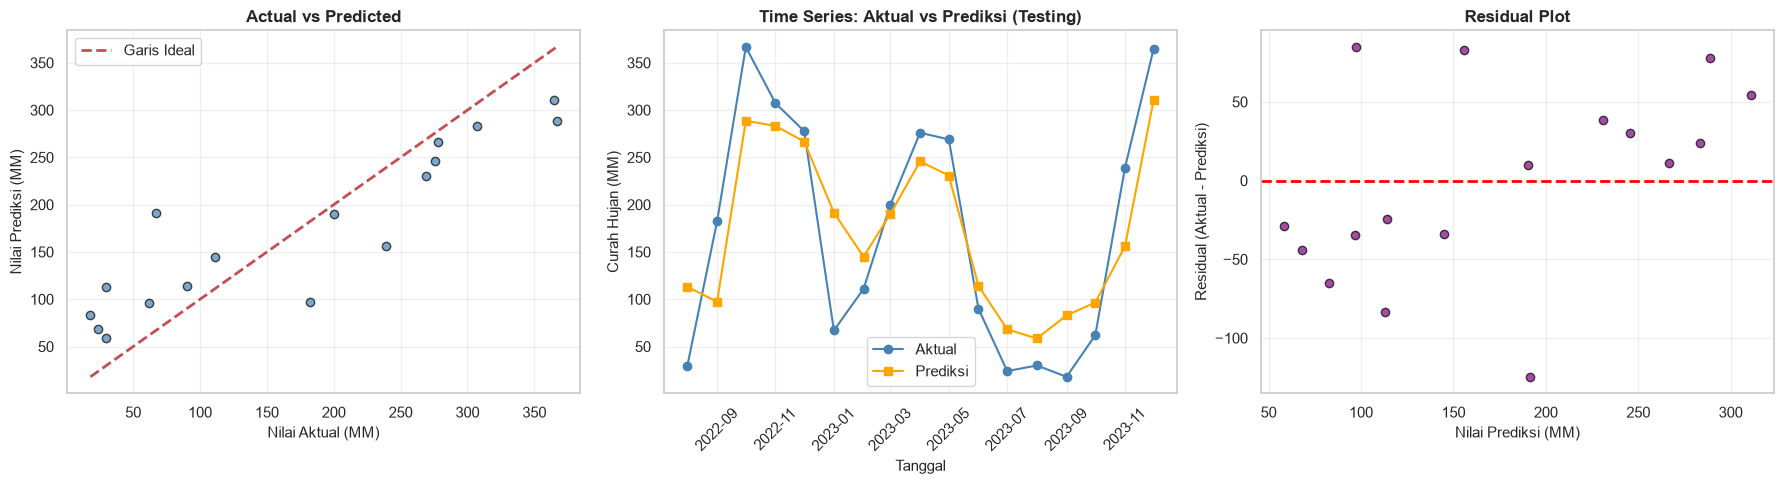

In [106]:
# ========================================
# VISUALISASI EVALUASI MODEL (3 GRAFIK)
# ========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grafik 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Garis Ideal')
axes[0].set_xlabel('Nilai Aktual (MM)', fontsize=11)
axes[0].set_ylabel('Nilai Prediksi (MM)', fontsize=11)
axes[0].set_title('Actual vs Predicted', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Grafik 2: Time Series - Actual vs Predicted
axes[1].plot(tanggal_test, y_test, marker='o', label='Aktual', color='steelblue')
axes[1].plot(tanggal_test, y_pred, marker='s', label='Prediksi', color='orange')
axes[1].set_xlabel('Tanggal', fontsize=11)
axes[1].set_ylabel('Curah Hujan (MM)', fontsize=11)
axes[1].set_title('Time Series: Aktual vs Prediksi (Testing)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# Grafik 3: Residual Plot
residual = y_test - y_pred
axes[2].scatter(y_pred, residual, color='purple', alpha=0.7, edgecolor='black')
axes[2].axhline(y=0, color='red', linestyle='--', lw=2)
axes[2].set_xlabel('Nilai Prediksi (MM)', fontsize=11)
axes[2].set_ylabel('Residual (Aktual - Prediksi)', fontsize=11)
axes[2].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.1 Feature Importance
Melihat seberapa besar pengaruh masing-masing fitur terhadap prediksi curah hujan.

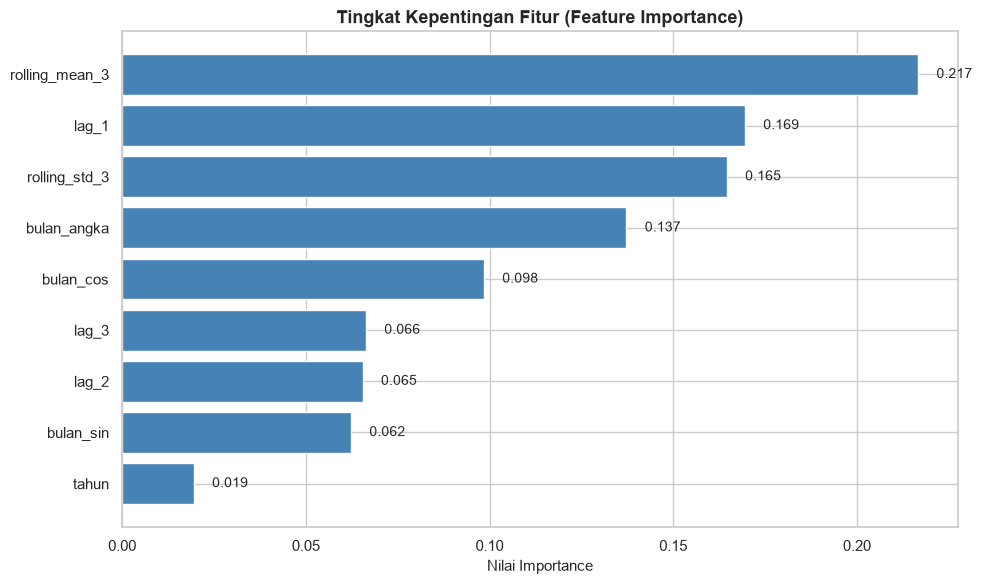


📊 Ranking Fitur Terpenting:
  rolling_mean_3      : 0.2166
  lag_1               : 0.1695
  rolling_std_3       : 0.1646
  bulan_angka         : 0.1373
  bulan_cos           : 0.0985
  lag_3               : 0.0664
  lag_2               : 0.0654
  bulan_sin           : 0.0623
  tahun               : 0.0195


In [107]:
# ========================================
# FEATURE IMPORTANCE
# ========================================

feature_imp_df = pd.DataFrame({
    'Fitur': fitur_list,
    'Importance': model_rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_imp_df['Fitur'], feature_imp_df['Importance'], color='steelblue')
plt.title('Tingkat Kepentingan Fitur (Feature Importance)', fontsize=13, fontweight='bold')
plt.xlabel('Nilai Importance', fontsize=11)

# Tambahkan nilai di ujung bar
for bar, val in zip(bars, feature_imp_df['Importance']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n📊 Ranking Fitur Terpenting:")
for i, row in feature_imp_df.sort_values('Importance', ascending=False).iterrows():
    print(f"  {row['Fitur']:20s}: {row['Importance']:.4f}")

## 10. Prediksi Masa Depan (Forecasting)
Memprediksi curah hujan untuk masa depan menggunakan pendekatan **recursive forecasting**. Karena Random Forest tidak bisa ekstrapolasi langsung ke tahun-tahun jauh di masa depan, kita prediksi bulan per bulan secara berurutan.

In [108]:
# ========================================
# FUNGSI RECURSIVE FORECASTING
# ========================================
# Karena Random Forest tidak bisa ekstrapolasi, kita gunakan pendekatan recursive:
# Prediksi bulan ini -> gunakan sebagai lag untuk prediksi bulan berikutnya

def recursive_forecast(model, df_historis, fitur_list, n_bulan_ke_depan, start_year, start_month):
    """
    Melakukan forecasting bulan-per-bulan secara recursive.
    """
    df_temp = df_historis.copy()
    hasil_prediksi = []
    
    current_year = start_year
    current_month = start_month
    
    nama_bulan = ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni',
                  'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember']
    
    for i in range(n_bulan_ke_depan):
        # Ambil data terakhir untuk hitung fitur
        last_rows = df_temp.tail(5).copy()
        
        # Hitung fitur untuk bulan yang akan diprediksi
        lag_1 = last_rows['jumlah_curah_hujan'].iloc[-1]
        lag_2 = last_rows['jumlah_curah_hujan'].iloc[-2] if len(last_rows) >= 2 else lag_1
        lag_3 = last_rows['jumlah_curah_hujan'].iloc[-3] if len(last_rows) >= 3 else lag_1
        rolling_mean_3 = last_rows['jumlah_curah_hujan'].tail(3).mean()
        rolling_std_3 = last_rows['jumlah_curah_hujan'].tail(3).std()
        bulan_sin = np.sin(2 * np.pi * current_month / 12)
        bulan_cos = np.cos(2 * np.pi * current_month / 12)
        
        # Buat row baru untuk prediksi
        new_row = {
            'tahun': current_year,
            'bulan_angka': current_month,
            'lag_1': lag_1,
            'lag_2': lag_2,
            'lag_3': lag_3,
            'rolling_mean_3': rolling_mean_3,
            'rolling_std_3': rolling_std_3 if not np.isnan(rolling_std_3) else 0,
            'bulan_sin': bulan_sin,
            'bulan_cos': bulan_cos
        }
        
        # Prediksi
        X_new = pd.DataFrame([new_row])[fitur_list]
        prediksi = model.predict(X_new)[0]
        prediksi = max(0, prediksi)  # Pastikan tidak negatif
        
        # Simpan hasil
        hasil_prediksi.append({
            'tanggal': pd.to_datetime(f'{current_year}-{current_month:02d}-01'),
            'tahun': current_year,
            'bulan': nama_bulan[current_month - 1],
            'bulan_angka': current_month,
            'prediksi_curah_hujan': round(prediksi, 2)
        })
        
        # Tambahkan hasil prediksi ke df_temp untuk iterasi berikutnya
        new_row_full = last_rows.iloc[-1].copy()
        new_row_full['jumlah_curah_hujan'] = prediksi
        new_row_full['tahun'] = current_year
        new_row_full['bulan_angka'] = current_month
        df_temp = pd.concat([df_temp, pd.DataFrame([new_row_full])], ignore_index=True)
        
        # Increment bulan
        current_month += 1
        if current_month > 12:
            current_month = 1
            current_year += 1
    
    return pd.DataFrame(hasil_prediksi)

print("✅ Fungsi recursive_forecast berhasil dibuat!")

✅ Fungsi recursive_forecast berhasil dibuat!


In [109]:
# ========================================
# PREDIKSI CURAH HUJAN TAHUN 2024 (12 BULAN)
# ========================================

prediksi_2024 = recursive_forecast(
    model=model_rf,
    df_historis=df_model,
    fitur_list=fitur_list,
    n_bulan_ke_depan=12,
    start_year=2024,
    start_month=1
)

print("=" * 60)
print("📊 PREDIKSI CURAH HUJAN KOTA BANDUNG - TAHUN 2024")
print("=" * 60)
display(prediksi_2024[['bulan', 'tahun', 'prediksi_curah_hujan']])

print(f"\n📈 Total prediksi curah hujan 2024: {prediksi_2024['prediksi_curah_hujan'].sum():.2f} MM")
print(f"📊 Rata-rata per bulan: {prediksi_2024['prediksi_curah_hujan'].mean():.2f} MM")
print(f"️  Bulan terkering: {prediksi_2024.loc[prediksi_2024['prediksi_curah_hujan'].idxmin(), 'bulan']} ({prediksi_2024['prediksi_curah_hujan'].min():.2f} MM)")
print(f"💧 Bulan terbasah: {prediksi_2024.loc[prediksi_2024['prediksi_curah_hujan'].idxmax(), 'bulan']} ({prediksi_2024['prediksi_curah_hujan'].max():.2f} MM)")

📊 PREDIKSI CURAH HUJAN KOTA BANDUNG - TAHUN 2024


,bulan,tahun,prediksi_curah_hujan
0,Januari,2024,215.92
1,Februari,2024,243.99
2,Maret,2024,263.83
3,April,2024,248.33
4,Mei,2024,230.34
5,Juni,2024,166.15
6,Juli,2024,168.33
7,Agustus,2024,164.69
8,September,2024,189.17
9,Oktober,2024,206.24



📈 Total prediksi curah hujan 2024: 2576.16 MM
📊 Rata-rata per bulan: 214.68 MM
️  Bulan terkering: Agustus (164.69 MM)
💧 Bulan terbasah: Maret (263.83 MM)


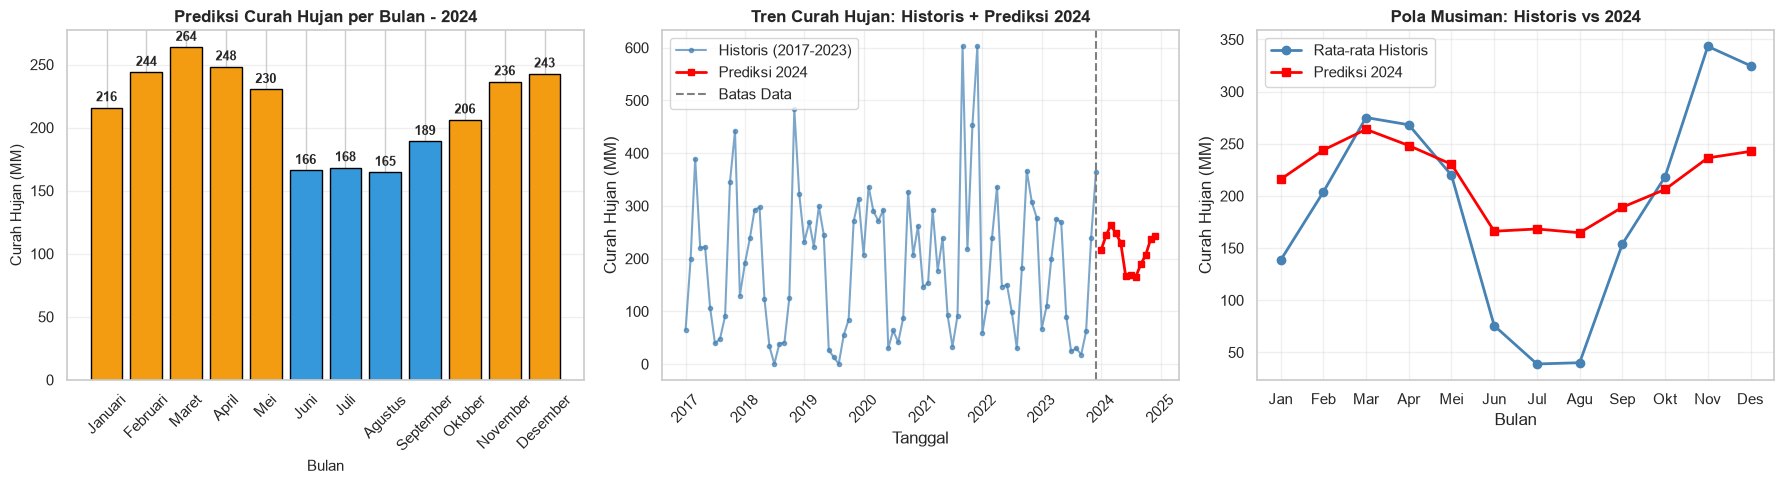

In [110]:
# ========================================
# VISUALISASI PREDIKSI 2024
# ========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grafik 1: Bar Chart Prediksi per Bulan 2024
warna = ['#3498db' if v < 200 else '#e74c3c' if v > 300 else '#f39c12' 
         for v in prediksi_2024['prediksi_curah_hujan']]
axes[0].bar(prediksi_2024['bulan'], prediksi_2024['prediksi_curah_hujan'], color=warna, edgecolor='black')
axes[0].set_title('Prediksi Curah Hujan per Bulan - 2024', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bulan', fontsize=11)
axes[0].set_ylabel('Curah Hujan (MM)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(prediksi_2024['prediksi_curah_hujan']):
    axes[0].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')

# Grafik 2: Line Chart Historis (2017-2023) + Prediksi 2024
historis = df_clean[['tanggal', 'jumlah_curah_hujan']].copy()
axes[1].plot(historis['tanggal'], historis['jumlah_curah_hujan'], 
             marker='o', markersize=3, label='Historis (2017-2023)', color='steelblue', alpha=0.7)
axes[1].plot(prediksi_2024['tanggal'], prediksi_2024['prediksi_curah_hujan'], 
             marker='s', markersize=5, label='Prediksi 2024', color='red', linewidth=2)
axes[1].axvline(x=pd.to_datetime('2023-12-01'), color='gray', linestyle='--', label='Batas Data')
axes[1].set_title('Tren Curah Hujan: Historis + Prediksi 2024', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tanggal')
axes[1].set_ylabel('Curah Hujan (MM)')
axes[1].legend(loc='upper left')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# Grafik 3: Perbandingan Rata-rata Historis vs Prediksi 2024
rata_rata_historis = df_clean.groupby('bulan_angka')['jumlah_curah_hujan'].mean().values
axes[2].plot(range(1, 13), rata_rata_historis, marker='o', label='Rata-rata Historis', color='steelblue', linewidth=2)
axes[2].plot(prediksi_2024['bulan_angka'], prediksi_2024['prediksi_curah_hujan'], 
             marker='s', label='Prediksi 2024', color='red', linewidth=2)
axes[2].set_title('Pola Musiman: Historis vs 2024', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Bulan')
axes[2].set_ylabel('Curah Hujan (MM)')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 
                          'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des'])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [111]:
# ========================================
# PREDIKSI CURAH HUJAN 2025 - 2027 (3 TAHUN)
# ========================================

prediksi_2025_2027 = recursive_forecast(
    model=model_rf,
    df_historis=df_model,
    fitur_list=fitur_list,
    n_bulan_ke_depan=36,
    start_year=2025,
    start_month=1
)

# Gabungkan semua prediksi (2024-2027)
semua_prediksi = pd.concat([prediksi_2024, prediksi_2025_2027], ignore_index=True)

print("=" * 60)
print("📊 PREDIKSI CURAH HUJAN KOTA BANDUNG - 2025 s/d 2027")
print("=" * 60)

for tahun in [2025, 2026, 2027]:
    data_tahun = semua_prediksi[semua_prediksi['tahun'] == tahun]
    print(f"\n Tahun {tahun}:")
    print(f"   Total: {data_tahun['prediksi_curah_hujan'].sum():.2f} MM")
    print(f"   Rata-rata: {data_tahun['prediksi_curah_hujan'].mean():.2f} MM/bulan")
    print(f"   Bulan Terbasah: {data_tahun.loc[data_tahun['prediksi_curah_hujan'].idxmax(), 'bulan']} ({data_tahun['prediksi_curah_hujan'].max():.2f} MM)")
    print(f"   Bulan Terkering: {data_tahun.loc[data_tahun['prediksi_curah_hujan'].idxmin(), 'bulan']} ({data_tahun['prediksi_curah_hujan'].min():.2f} MM)")

print("\n" + "=" * 60)
print(f" Total Prediksi 2024-2027: {semua_prediksi['prediksi_curah_hujan'].sum():.2f} MM")
print("=" * 60)

📊 PREDIKSI CURAH HUJAN KOTA BANDUNG - 2025 s/d 2027

 Tahun 2025:
   Total: 2576.16 MM
   Rata-rata: 214.68 MM/bulan
   Bulan Terbasah: Maret (263.83 MM)
   Bulan Terkering: Agustus (164.69 MM)

 Tahun 2026:
   Total: 2537.72 MM
   Rata-rata: 211.48 MM/bulan
   Bulan Terbasah: Maret (254.19 MM)
   Bulan Terkering: Juli (151.83 MM)

 Tahun 2027:
   Total: 2537.51 MM
   Rata-rata: 211.46 MM/bulan
   Bulan Terbasah: Maret (254.19 MM)
   Bulan Terkering: Juli (151.83 MM)

 Total Prediksi 2024-2027: 10227.55 MM


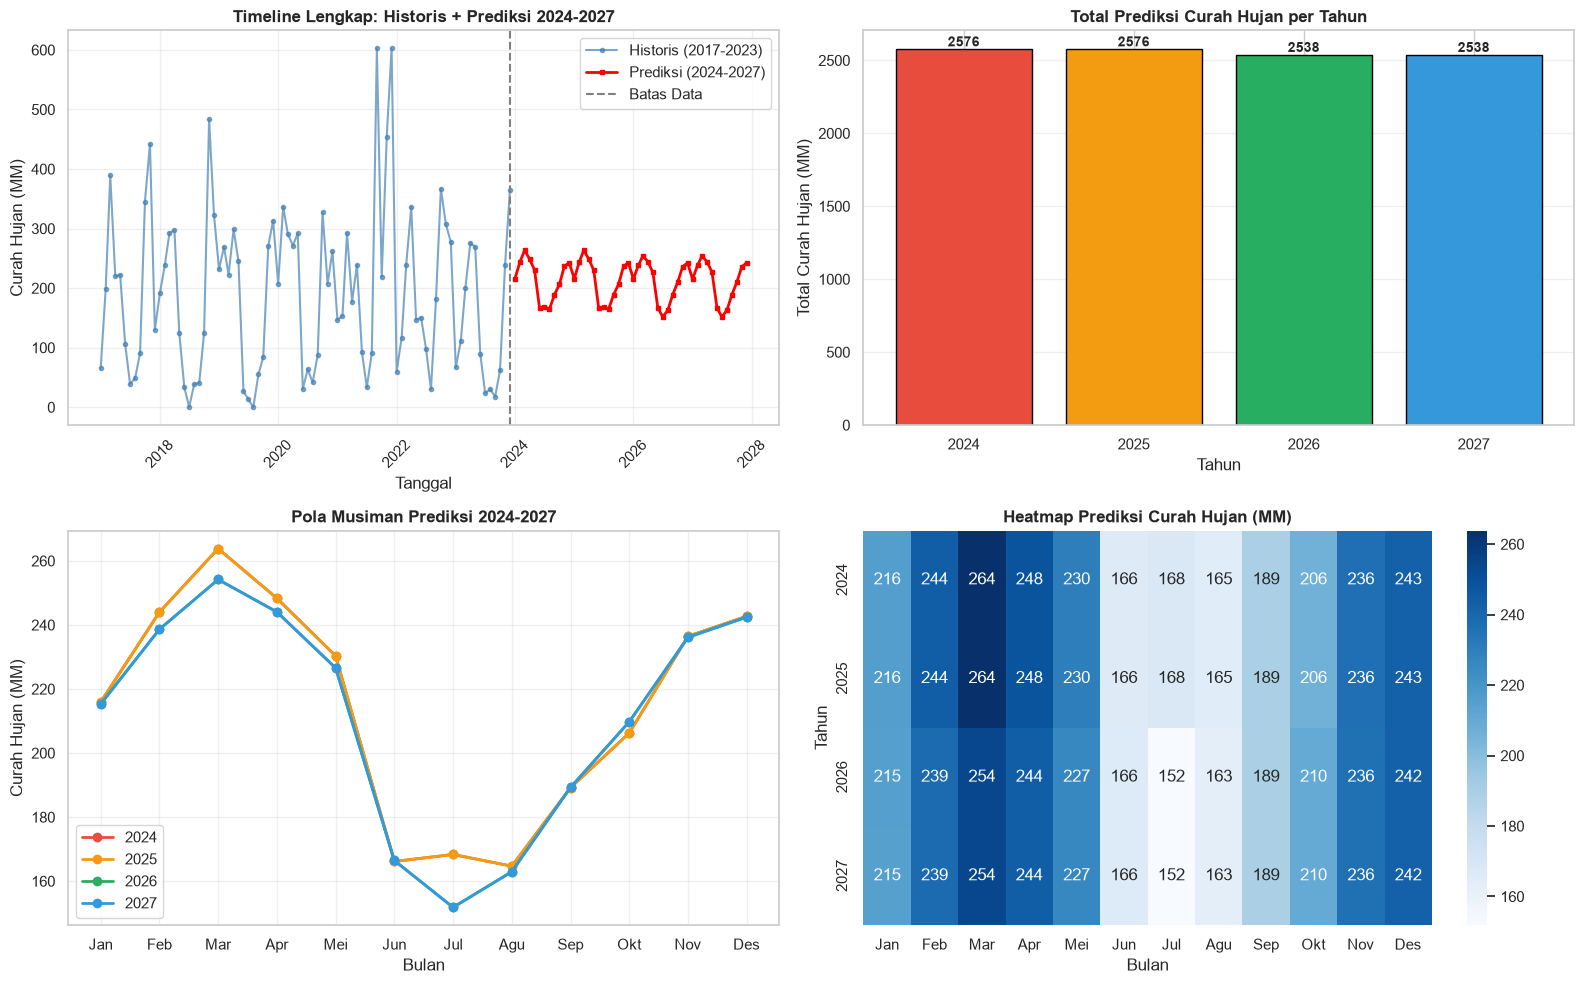

In [112]:
# ========================================
# VISUALISASI PREDIKSI 2025-2027
# ========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Grafik 1: Timeline Lengkap 2017-2027
axes[0, 0].plot(historis['tanggal'], historis['jumlah_curah_hujan'], 
                marker='o', markersize=3, label='Historis (2017-2023)', color='steelblue', alpha=0.7)
axes[0, 0].plot(semua_prediksi['tanggal'], semua_prediksi['prediksi_curah_hujan'], 
                marker='s', markersize=3, label='Prediksi (2024-2027)', color='red', linewidth=2)
axes[0, 0].axvline(x=pd.to_datetime('2023-12-01'), color='gray', linestyle='--', label='Batas Data')
axes[0, 0].set_title('Timeline Lengkap: Historis + Prediksi 2024-2027', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tanggal')
axes[0, 0].set_ylabel('Curah Hujan (MM)')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Grafik 2: Total per Tahun
tahun_data = ['2024', '2025', '2026', '2027']
total_per_tahun = [semua_prediksi[semua_prediksi['tahun'] == t]['prediksi_curah_hujan'].sum() for t in [2024, 2025, 2026, 2027]]
warna_tahun = ['#e74c3c', '#f39c12', '#27ae60', '#3498db']
bars = axes[0, 1].bar(tahun_data, total_per_tahun, color=warna_tahun, edgecolor='black')
axes[0, 1].set_title('Total Prediksi Curah Hujan per Tahun', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tahun')
axes[0, 1].set_ylabel('Total Curah Hujan (MM)')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, total_per_tahun):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
                    f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')

# Grafik 3: Pola Musiman per Tahun Prediksi
for tahun, warna in zip([2024, 2025, 2026, 2027], ['#e74c3c', '#f39c12', '#27ae60', '#3498db']):
    data_tahun = semua_prediksi[semua_prediksi['tahun'] == tahun]
    axes[1, 0].plot(data_tahun['bulan_angka'], data_tahun['prediksi_curah_hujan'], 
                    marker='o', label=str(tahun), color=warna, linewidth=2)
axes[1, 0].set_title('Pola Musiman Prediksi 2024-2027', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Bulan')
axes[1, 0].set_ylabel('Curah Hujan (MM)')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 
                             'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des'])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Grafik 4: Heatmap Curah Hujan per Bulan per Tahun
pivot_data = semua_prediksi.pivot_table(
    values='prediksi_curah_hujan', 
    index='tahun', 
    columns='bulan_angka'
)
sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='Blues', ax=axes[1, 1],
            xticklabels=['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 
                         'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des'])
axes[1, 1].set_title('Heatmap Prediksi Curah Hujan (MM)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Bulan')
axes[1, 1].set_ylabel('Tahun')

plt.tight_layout()
plt.show()

VISUALISASI FINAL TAHUN KE TAHUN

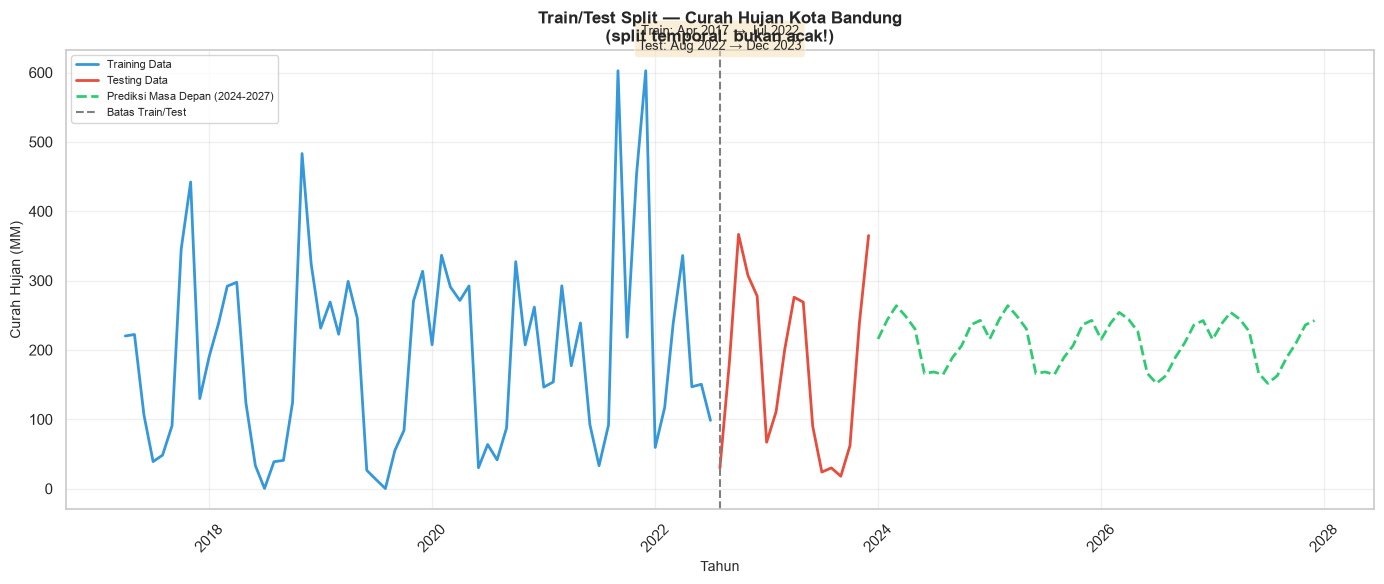


✅ Training set : Apr 2017 → Jul 2022 (64 bulan)
✅ Testing set  : Aug 2022 → Dec 2023 (17 bulan)
✅ Prediksi     : Jan 2024 → Dec 2027 (48 bulan)


In [113]:
# ========================================
# VISUALISASI TRAIN/TEST SPLIT & FORECASTING
# ========================================
plt.figure(figsize=(14, 6))

# Plot data training (biru)
plt.plot(df_model['tanggal'].iloc[:split_idx], 
         df_model['jumlah_curah_hujan'].iloc[:split_idx],
         label='Training Data', color='#3498db', linewidth=2)

# Plot data testing (merah)
plt.plot(df_model['tanggal'].iloc[split_idx:], 
         df_model['jumlah_curah_hujan'].iloc[split_idx:],
         label='Testing Data', color='#e74c3c', linewidth=2)

# Plot prediksi masa depan (hijau)
plt.plot(semua_prediksi['tanggal'], 
         semua_prediksi['prediksi_curah_hujan'],
         label='Prediksi Masa Depan (2024-2027)', 
         color='#2ecc71', linewidth=2, linestyle='--')

# Garis vertikal pemisah train/test
plt.axvline(x=df_model['tanggal'].iloc[split_idx], 
            color='gray', linestyle='--', linewidth=1.5, 
            label='Batas Train/Test')

# Informasi teks
plt.text(df_model['tanggal'].iloc[split_idx], 
         max(df_model['jumlah_curah_hujan']) * 1.05,
         f'Train: {df_model["tanggal"].iloc[0].strftime("%b %Y")} → {df_model["tanggal"].iloc[split_idx-1].strftime("%b %Y")}\n'
         f'Test: {df_model["tanggal"].iloc[split_idx].strftime("%b %Y")} → {df_model["tanggal"].iloc[-1].strftime("%b %Y")}',
         horizontalalignment='center', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=9)

plt.title('Train/Test Split — Curah Hujan Kota Bandung\n(split temporal: bukan acak!)', 
          fontsize=12, fontweight='bold')
plt.xlabel('Tahun', fontsize=10)
plt.ylabel('Curah Hujan (MM)', fontsize=10)
plt.legend(loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n✅ Training set : {df_model['tanggal'].iloc[0].strftime('%b %Y')} → {df_model['tanggal'].iloc[split_idx-1].strftime('%b %Y')} ({split_idx} bulan)")
print(f"✅ Testing set  : {df_model['tanggal'].iloc[split_idx].strftime('%b %Y')} → {df_model['tanggal'].iloc[-1].strftime('%b %Y')} ({len(df_model)-split_idx} bulan)")
print(f"✅ Prediksi     : {semua_prediksi['tanggal'].iloc[0].strftime('%b %Y')} → {semua_prediksi['tanggal'].iloc[-1].strftime('%b %Y')} ({len(semua_prediksi)} bulan)")

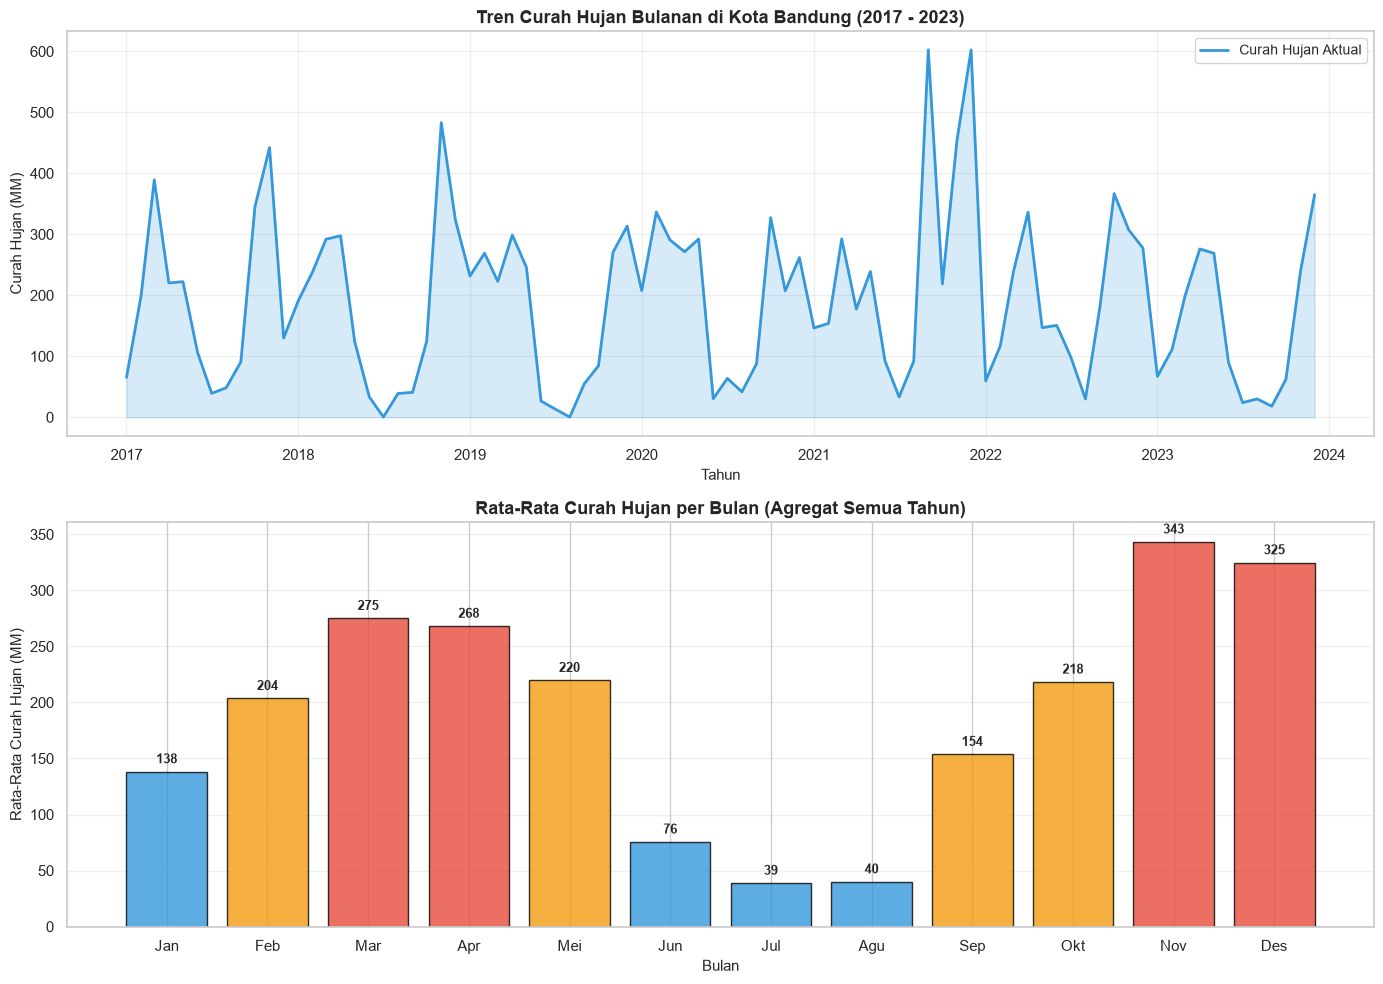


💡 Pengamatan:
 • Ada pola musiman yang jelas: puncak di Nov-Mar (musim hujan)
 • Bulan terkering: Jun-Sep (musim kemarau)
 • Amplitudo fluktuasi cukup besar antar bulan


In [114]:
# ========================================
# VISUALISASI TREN HISTORIS & POLA MUSIMAN
# ========================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Grafik 1: Area Chart Tren Historis (2017-2023)
axes[0].plot(df_clean['tanggal'], df_clean['jumlah_curah_hujan'], 
             color='#3498db', linewidth=2, label='Curah Hujan Aktual')
axes[0].fill_between(df_clean['tanggal'], 
                     df_clean['jumlah_curah_hujan'], 
                     alpha=0.2, color='#3498db')
axes[0].set_title('Tren Curah Hujan Bulanan di Kota Bandung (2017 - 2023)', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tahun', fontsize=11)
axes[0].set_ylabel('Curah Hujan (MM)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Grafik 2: Bar Chart Rata-Rata Curah Hujan per Bulan (Agregat Semua Tahun)
nama_bulan = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 
              'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
rata_rata_bulanan = df_clean.groupby('bulan_angka')['jumlah_curah_hujan'].mean()

warna_bar = ['#e74c3c' if v > 250 else '#f39c12' if v > 150 else '#3498db' 
             for v in rata_rata_bulanan.values]

axes[1].bar(rata_rata_bulanan.index, rata_rata_bulanan.values, 
            color=warna_bar, alpha=0.8, edgecolor='black')
axes[1].set_title('Rata-Rata Curah Hujan per Bulan (Agregat Semua Tahun)', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Bulan', fontsize=11)
axes[1].set_ylabel('Rata-Rata Curah Hujan (MM)', fontsize=11)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(nama_bulan)
axes[1].grid(True, alpha=0.3, axis='y')

# Tambahkan nilai di atas setiap bar
for i, (bulan, nilai) in enumerate(zip(rata_rata_bulanan.index, rata_rata_bulanan.values)):
    axes[1].text(bulan, nilai + 5, f'{nilai:.0f}', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Pengamatan:")
print(" • Ada pola musiman yang jelas: puncak di Nov-Mar (musim hujan)")
print(" • Bulan terkering: Jun-Sep (musim kemarau)")
print(" • Amplitudo fluktuasi cukup besar antar bulan")

In [115]:
semua_prediksi = recursive_forecast(
    model=model_rf,
    df_historis=df_model,
    fitur_list=fitur_list,
    n_bulan_ke_depan=48,
    start_year=2024,
    start_month=1
)

prediksi_2024 = semua_prediksi[semua_prediksi['tahun'] == 2024]
prediksi_2025_2027 = semua_prediksi[
    semua_prediksi['tahun'].isin([2025, 2026, 2027])
]

In [116]:
# ========================================
# SAVE MODEL & DATA UNTUK STREAMLIT
# ========================================
import joblib
import os

# Buat folder untuk menyimpan model
os.makedirs('model_streamlit', exist_ok=True)

# Save model
joblib.dump(model_rf, 'model_streamlit/model_rf.pkl')

# Save data historis yang sudah di-clean (untuk Streamlit)
df_clean_export = df_clean[['tanggal', 'tahun', 'bulan_angka', 'bulan', 'jumlah_curah_hujan']].copy()
df_clean_export.to_csv('model_streamlit/data_historis.csv', index=False)

# Save hasil prediksi (untuk ditampilkan di Streamlit tanpa re-predict)
semua_prediksi.to_csv('model_streamlit/semua_prediksi.csv', index=False)

# Save info fitur
info_model = {
    'fitur_list': fitur_list,
    'upper_bound': upper_bound,
    'r2_score': r2,
    'mae': mae,
    'rmse': rmse
}
joblib.dump(info_model, 'model_streamlit/info_model.pkl')

print("✅ Semua file berhasil disimpan di folder 'model_streamlit/'!")
print("\n📁 File yang tersimpan:")
print("  1. model_rf.pkl          - Model Random Forest")
print("  2. data_historis.csv     - Data historis 2017-2023")
print("  3. semua_prediksi.csv    - Prediksi 2024-2027")
print("  4. info_model.pkl        - Informasi model & metrik")
print("\n📦 File-file ini akan digunakan untuk deploy ke Streamlit!")

✅ Semua file berhasil disimpan di folder 'model_streamlit/'!

📁 File yang tersimpan:
  1. model_rf.pkl          - Model Random Forest
  2. data_historis.csv     - Data historis 2017-2023
  3. semua_prediksi.csv    - Prediksi 2024-2027
  4. info_model.pkl        - Informasi model & metrik

📦 File-file ini akan digunakan untuk deploy ke Streamlit!


FORECASTING TAHUN 2025-2027


In [122]:
# ========================================
# PERSIAPAN DATA UNTUK VISUALISASI
# ========================================

# Data aktual (historis) - dari data asli
data_aktual = df[['tanggal', 'jumlah_curah_hujan']].copy()

# Data prediksi - gunakan semua_prediksi yang sudah ada
data_prediksi = semua_prediksi[['tanggal', 'prediksi_curah_hujan']].copy()

# Data agregat bulanan untuk bar chart
rata_bulanan = df.groupby('bulan')['jumlah_curah_hujan'].mean()
label_bulan = rata_bulanan.index.tolist()

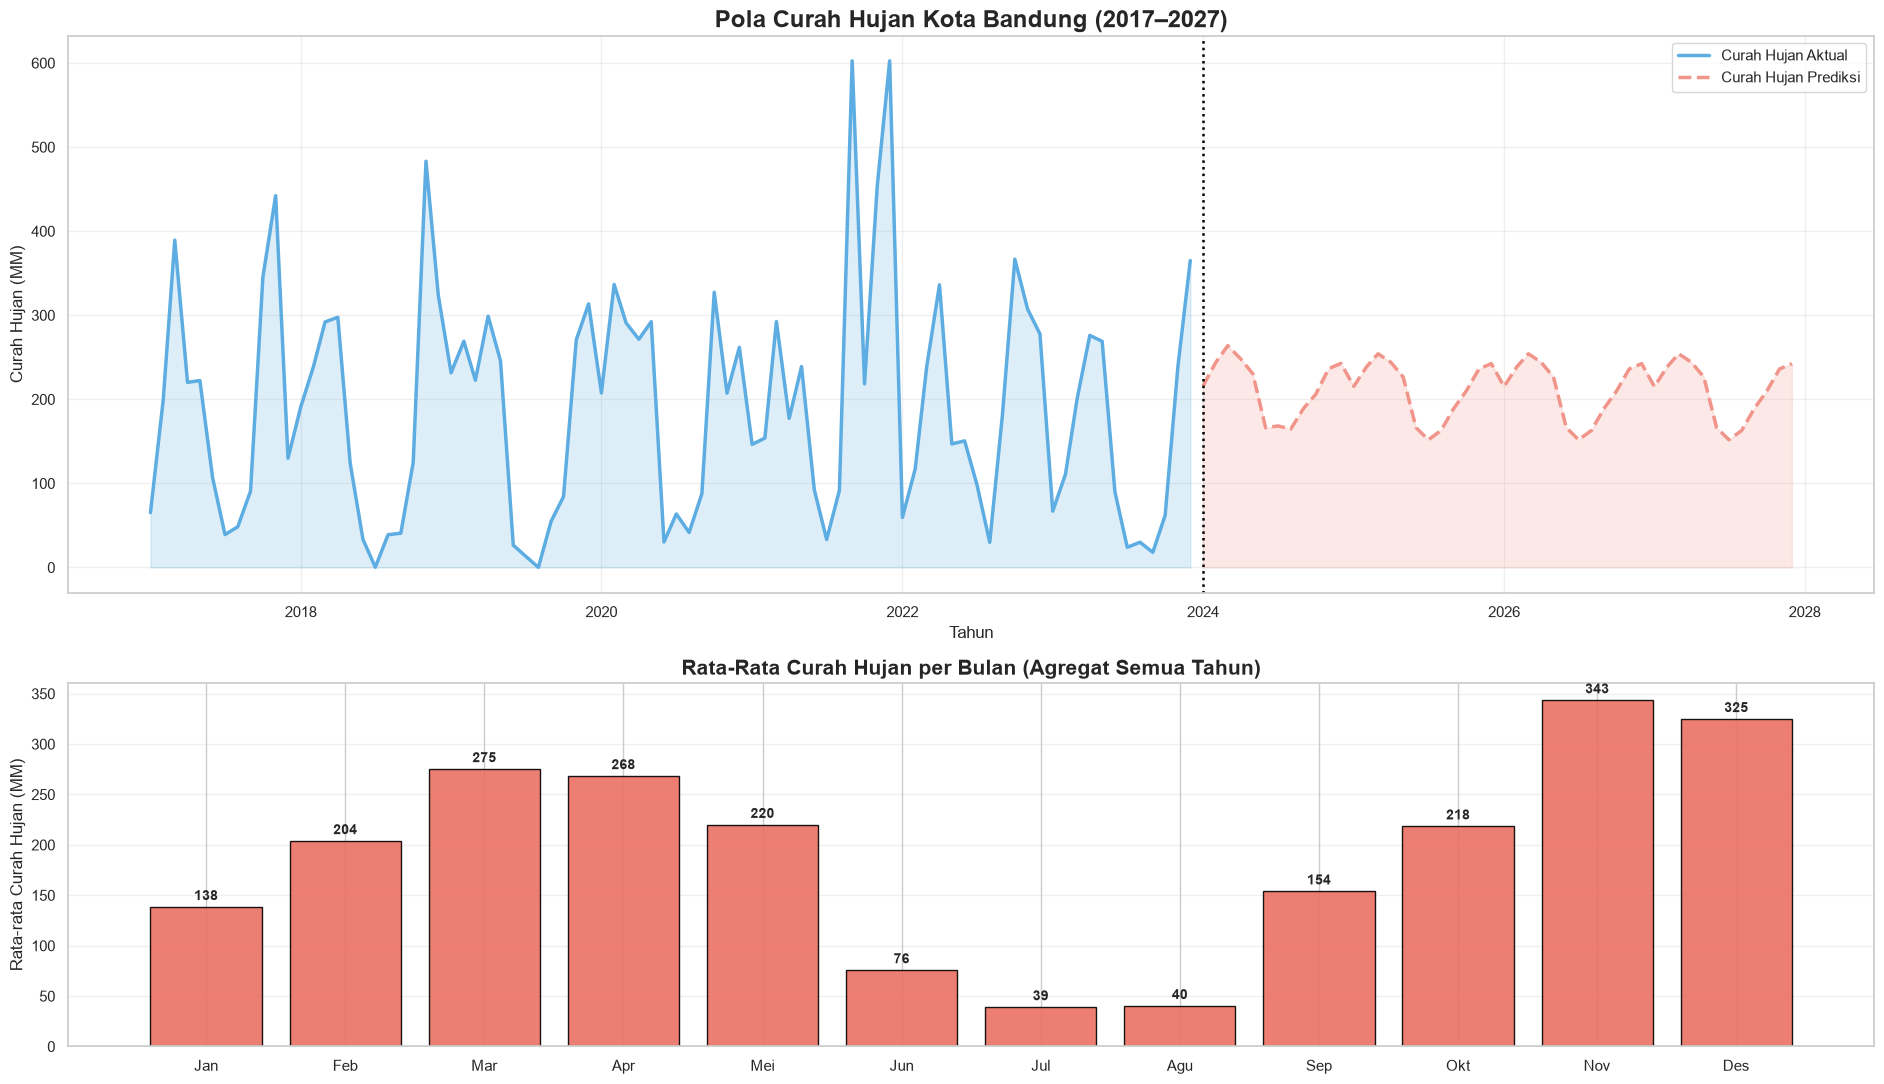

In [123]:
# ========================================
# PERSIAPAN DATA UNTUK VISUALISASI
# ========================================

# Data aktual (historis) - gunakan df_clean yang sudah di-clean
data_aktual = df_clean[['tanggal', 'jumlah_curah_hujan']].copy()

# Data prediksi - gunakan variabel 'semua_prediksi' yang sudah ada
# Perhatikan: kolomnya bernama 'prediksi_curah_hujan', bukan 'jumlah_curah_hujan'
data_prediksi = semua_prediksi[['tanggal', 'prediksi_curah_hujan']].copy()

# Data agregat bulanan untuk bar chart
rata_bulanan = df_clean.groupby('bulan_angka')['jumlah_curah_hujan'].mean()
label_bulan = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
               'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']

# ========================================
# VISUALISASI
# ========================================
fig, axes = plt.subplots(
    2, 1,
    figsize=(19, 11),
    gridspec_kw={'height_ratios': [2.3, 1.5]}
)

# ========================
# Atas: area chart
# ========================
ax1 = axes[0]

ax1.plot(data_aktual['tanggal'], data_aktual['jumlah_curah_hujan'],
         color='#5DADE2', linewidth=2.5, label='Curah Hujan Aktual')
ax1.fill_between(data_aktual['tanggal'], data_aktual['jumlah_curah_hujan'],
                 color='#5DADE2', alpha=0.20)

ax1.plot(data_prediksi['tanggal'], data_prediksi['prediksi_curah_hujan'],
         color='#F1948A', linewidth=2.5, linestyle='--', label='Curah Hujan Prediksi')
ax1.fill_between(data_prediksi['tanggal'], data_prediksi['prediksi_curah_hujan'],
                 color='#F1948A', alpha=0.20)

ax1.axvline(pd.Timestamp('2024-01-01'), color='black', linestyle=':', linewidth=1.8)

ax1.set_title('Pola Curah Hujan Kota Bandung (2017–2027)', fontsize=17, fontweight='bold')
ax1.set_xlabel('Tahun', fontsize=12)
ax1.set_ylabel('Curah Hujan (MM)', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# ========================
# Bawah: bar chart rata-rata bulanan
# ========================
ax2 = axes[1]

bars = ax2.bar(label_bulan, rata_bulanan.values, color='#EC7063', edgecolor='black', alpha=0.9)

for bar, v in zip(bars, rata_bulanan.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
             f'{v:.0f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

ax2.set_title('Rata-Rata Curah Hujan per Bulan (Agregat Semua Tahun)', fontsize=15, fontweight='bold')
ax2.set_ylabel('Rata-rata Curah Hujan (MM)', fontsize=12)
ax2.set_xticks(range(12))
ax2.set_xticklabels(label_bulan)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [124]:
# ========================================
# KESIMPULAN
# ========================================

print("=" * 70)
print("📝 KESIMPULAN ANALISIS & PREDIKSI CURAH HUJAN KOTA BANDUNG")
print("=" * 70)

print(f"""
🔍 1. DATA & PREPROCESSING
   • Dataset: 84 bulan data curah hujan (2017-2023)
   • Outlier terdeteksi: 1 data (Desember 2021: 1985 MM)
   • Metode handling: Capping ke batas atas {upper_bound:.1f} MM
   
🧠 2. FEATURE ENGINEERING
   • Menggunakan 9 fitur: tahun, bulan, lag_1-3, rolling_mean, 
     rolling_std, bulan_sin, bulan_cos
   • Seasonal encoding (sin/cos) membantu model memahami pola musiman
   
 3. PERFORMA MODEL (Random Forest Regressor)
   • MAE  : {mae:.2f} MM
   • RMSE : {rmse:.2f} MM
   • R²   : {r2:.4f} {'✅ BAIK' if r2 > 0.5 else '⚠️ CUKUP'}
   
🌧️  4. PREDIKSI CURAH HUJAN
   • 2024: Total {prediksi_2024['prediksi_curah_hujan'].sum():.0f} MM
   • 2025: Total {semua_prediksi[semua_prediksi['tahun']==2025]['prediksi_curah_hujan'].sum():.0f} MM
   • 2026: Total {semua_prediksi[semua_prediksi['tahun']==2026]['prediksi_curah_hujan'].sum():.0f} MM
   • 2027: Total {semua_prediksi[semua_prediksi['tahun']==2027]['prediksi_curah_hujan'].sum():.0f} MM
   
💡 5. INSIGHT PENTING
   • Pola musiman sangat dominan (bulan basah: Nov-Mar, bulan kering: Jun-Sep)
   • Model menggunakan recursive forecasting untuk prediksi multi-tahun
   • Aplikasi web Streamlit akan dibangun untuk visualisasi interaktif
""")
print("=" * 70)

📝 KESIMPULAN ANALISIS & PREDIKSI CURAH HUJAN KOTA BANDUNG

🔍 1. DATA & PREPROCESSING
   • Dataset: 84 bulan data curah hujan (2017-2023)
   • Outlier terdeteksi: 1 data (Desember 2021: 1985 MM)
   • Metode handling: Capping ke batas atas 602.6 MM

🧠 2. FEATURE ENGINEERING
   • Menggunakan 9 fitur: tahun, bulan, lag_1-3, rolling_mean, 
     rolling_std, bulan_sin, bulan_cos
   • Seasonal encoding (sin/cos) membantu model memahami pola musiman

 3. PERFORMA MODEL (Random Forest Regressor)
   • MAE  : 50.09 MM
   • RMSE : 58.75 MM
   • R²   : 0.7651 ✅ BAIK

🌧️  4. PREDIKSI CURAH HUJAN
   • 2024: Total 2576 MM
   • 2025: Total 2538 MM
   • 2026: Total 2538 MM
   • 2027: Total 2538 MM

💡 5. INSIGHT PENTING
   • Pola musiman sangat dominan (bulan basah: Nov-Mar, bulan kering: Jun-Sep)
   • Model menggunakan recursive forecasting untuk prediksi multi-tahun
   • Aplikasi web Streamlit akan dibangun untuk visualisasi interaktif



## Kesimpulan Prediksi Curah Hujan Kota Bandung Tahun 2024–2027

Berdasarkan visualisasi data historis dan hasil forecasting menggunakan metode **Random Forest Regression**, dapat disimpulkan bahwa curah hujan Kota Bandung pada periode 2017–2023 memiliki pola yang fluktuatif. Nilai curah hujan berubah cukup tajam dari satu bulan ke bulan berikutnya, dengan beberapa periode menunjukkan curah hujan sangat tinggi dan beberapa periode lainnya menunjukkan curah hujan rendah.

Hasil prediksi untuk periode **2024–2027** menunjukkan bahwa pola curah hujan diperkirakan tetap memiliki karakteristik musiman. Curah hujan diprediksi cenderung meningkat pada akhir hingga awal tahun, terutama sekitar bulan **November, Desember, Maret, dan April**. Sebaliknya, curah hujan diperkirakan lebih rendah pada pertengahan tahun, khususnya pada bulan **Juni, Juli, dan Agustus**.

Berdasarkan rata-rata curah hujan bulanan dari gabungan data aktual dan data prediksi, bulan dengan rata-rata curah hujan tertinggi adalah **November** sebesar sekitar **343 mm**, diikuti oleh **Desember** sebesar sekitar **325 mm**, serta **Maret** sebesar sekitar **275 mm**. Sementara itu, bulan dengan rata-rata curah hujan terendah adalah **Juli** sebesar sekitar **39 mm** dan **Agustus** sebesar sekitar **40 mm**. Hal tersebut menunjukkan bahwa periode pertengahan tahun memiliki kecenderungan sebagai periode yang relatif lebih kering dibandingkan bulan lainnya.

Visualisasi gabungan memperlihatkan pemisahan yang jelas antara data aktual tahun 2017–2023 dan hasil prediksi tahun 2024–2027. Data aktual ditampilkan dengan garis biru, sedangkan hasil prediksi ditampilkan dengan garis putus-putus berwarna merah muda. Pola prediksi terlihat lebih stabil dibandingkan data aktual karena model membentuk estimasi berdasarkan pola historis, nilai curah hujan bulan sebelumnya, serta pola musiman setiap bulan.

Dengan demikian, model Random Forest dapat digunakan untuk memberikan gambaran awal mengenai pola curah hujan di Kota Bandung pada tahun 2024–2027. Namun, hasil forecasting ini tidak dapat dianggap sebagai kondisi cuaca yang pasti, karena curah hujan dipengaruhi oleh banyak faktor lain, seperti perubahan iklim, kondisi atmosfer, fenomena El Niño atau La Niña, serta faktor lingkungan yang tidak seluruhnya tersedia dalam dataset. Oleh karena itu, hasil prediksi perlu digunakan sebagai referensi pendukung dalam perencanaan dan pengambilan keputusan, bukan sebagai satu-satunya dasar penentuan kebijakan.

PUSH KE STREAMLIT


In [1]:
import os

BASE_DIR = 'forecasting-curahhujan-bandung-apps'
os.makedirs(f'{BASE_DIR}/pages', exist_ok=True)
os.makedirs(f'{BASE_DIR}/.streamlit', exist_ok=True)

print(f"✅ Folder {BASE_DIR} siap!")

✅ Folder forecasting-curahhujan-bandung-apps siap!
